In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gseapy as gp
import os
import pickle

import subcluster_funcs as funcs
sc._settings.settings._vector_friendly=True

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
post_subclustering_dir = "../post_subcluster_annotation/"
os.makedirs(post_subclustering_dir, exist_ok=True)

In [3]:
cell_type = "Adipocyte"

In [4]:
adata = sc.read_h5ad("../post_subclustering/" + cell_type  + ".h5ad")

<Axes: xlabel='leiden', ylabel='sil_score'>

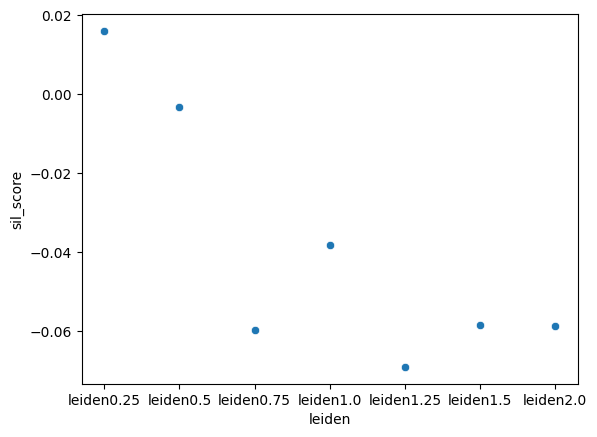

In [5]:
funcs.silhouette(adata, cell_type = cell_type)

### Leiden 0.25

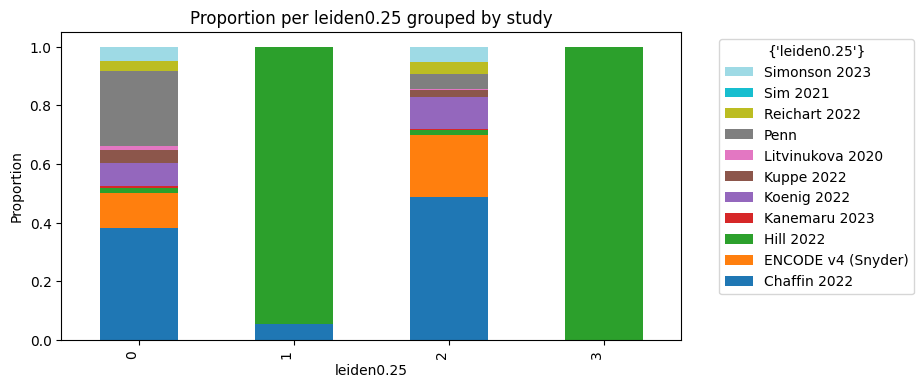

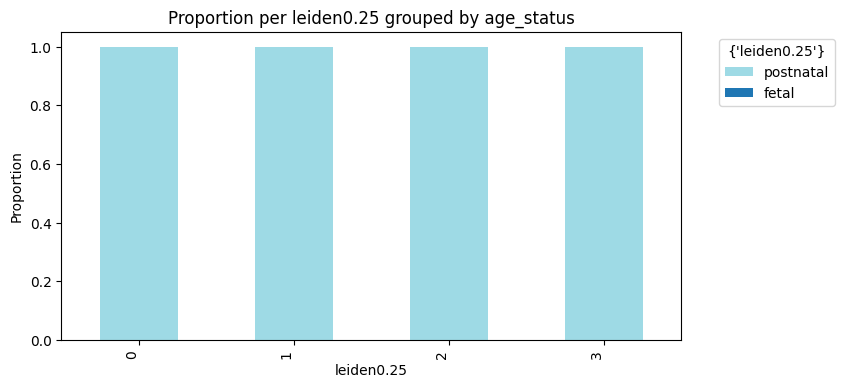

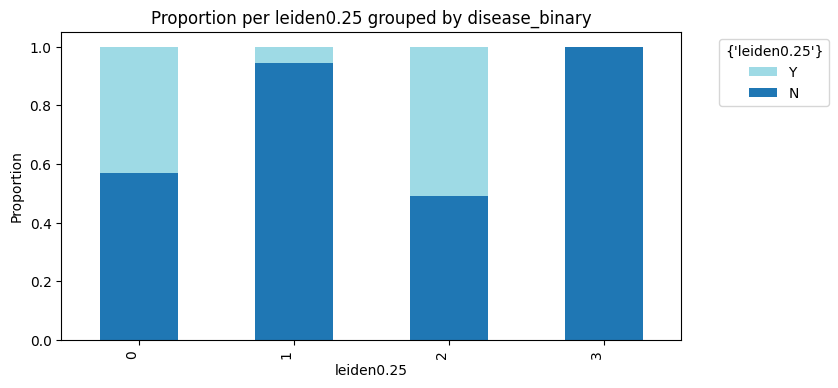

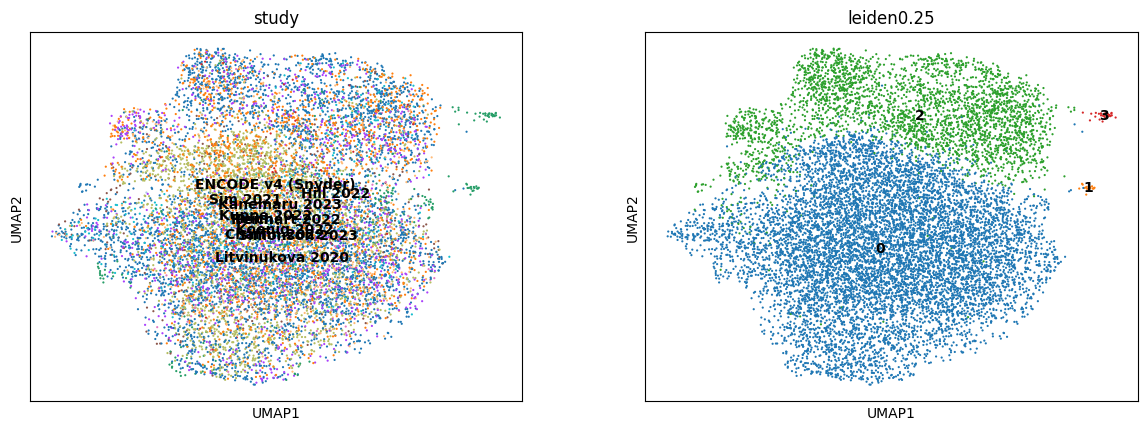

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean

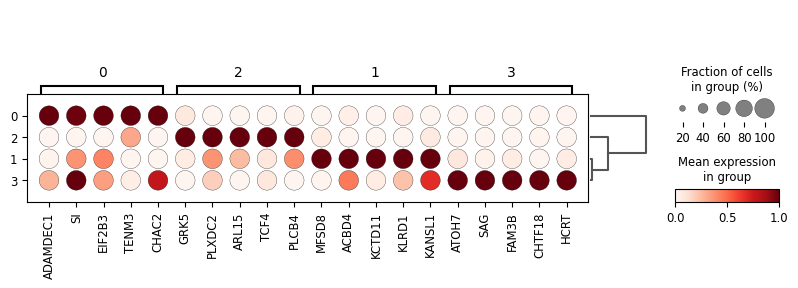

Counter({'0': 8961, '2': 3090, '3': 29, '1': 18})


['leiden0.25',
 AnnData object with n_obs × n_vars = 12098 × 16115
     obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0'
     var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0', 'neighbors', 'pca', 'rank_genes_groupsleiden0.1', 'rank_genes_groupsleiden0.25', 'rank_genes_groupsleiden0.5', 'rank_genes_groupsleiden0.75', 'rank_genes_groupsleiden1.0', '

In [6]:
funcs.specify_leiden_subclustering(adata=adata, leiden="leiden0.25")

- Clusters 1 and 3 are very small, belong primarily to one study
- Cluster 0 are clear white adipocytes (CIDEC/MLXIPL/TBX15)
- Cluster 2 is more associated with stromal interactions (IGFBP7/PLXDC2/CDH11)

In [12]:
adata.obs['subcluster'] = adata.obs['leiden0.25'].map(
    {"0": "White",
     "1": "Other",
     "2": "Stromal",
     "3": "Other",
    }
)

In [13]:
subcluster_order = [
    "White",
    "Stromal",
    "Other"
]

adata.obs['subcluster'] = pd.Categorical(
    adata.obs['subcluster'], categories=subcluster_order, ordered=True
)

# Define colors for each CM subcluster
subcluster_colors = {
    "White": "pink",       # gold
    "Stromal": "red",    # red
    "Other": "#D3D3D3"
}

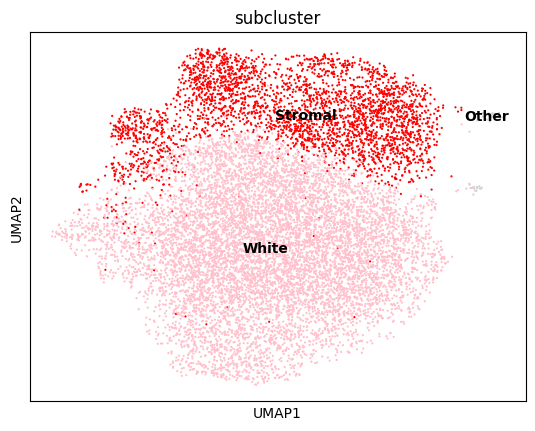

In [14]:
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['subcluster'], legend_loc = "on data", palette=subcluster_colors, show=False)
    plt.savefig("Adipocyte_subclustered.pdf", bbox_inches="tight")

- Cluster 0 are clear white adipocytes (CIDEC/MLXIPL/TBX15)
- Cluster 2 is more associated with stromal interactions (IGFBP7/PLXDC2/CDH11)

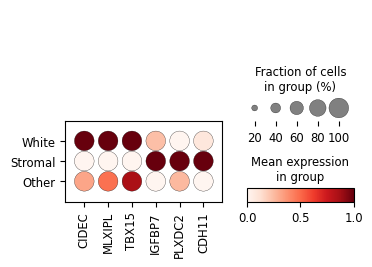

In [15]:
with plt.rc_context(): 
    sc.pl.dotplot(adata, var_names = ["CIDEC", "MLXIPL", "TBX15", 
                                      "IGFBP7", "PLXDC2", "CDH11"], groupby = "subcluster", 
                  show=False, standard_scale='var')
    plt.savefig("Adipocyte_subclustered_dotplot.pdf", bbox_inches="tight")

In [16]:
subcluster_stats = (
    adata.obs['subcluster']
    .value_counts(normalize=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "subcluster"})
)

subcluster_stats["proportion"] = subcluster_stats["count"] / subcluster_stats["count"].sum()

print(subcluster_stats)

  subcluster  count  proportion
0      White   8961    0.740701
1    Stromal   3090    0.255414
2      Other     47    0.003885
